In [1]:
import pandas as pd

# Load processed data
df = pd.read_csv("cleaned_data.csv")

df.drop("customerID", axis=1, inplace=True)

X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes":1, "No":0})

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [3]:
X_test_transformed = model.named_steps["preprocessor"].transform(X_test)

In [4]:
# Get feature names after encoding
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(cat_cols)

feature_names = list(num_cols) + list(encoded_cat_features)

In [5]:
import shap

# Create explainer
explainer = shap.Explainer(
    model.named_steps["classifier"],
    X_test_transformed
)

shap_values = explainer(X_test_transformed)

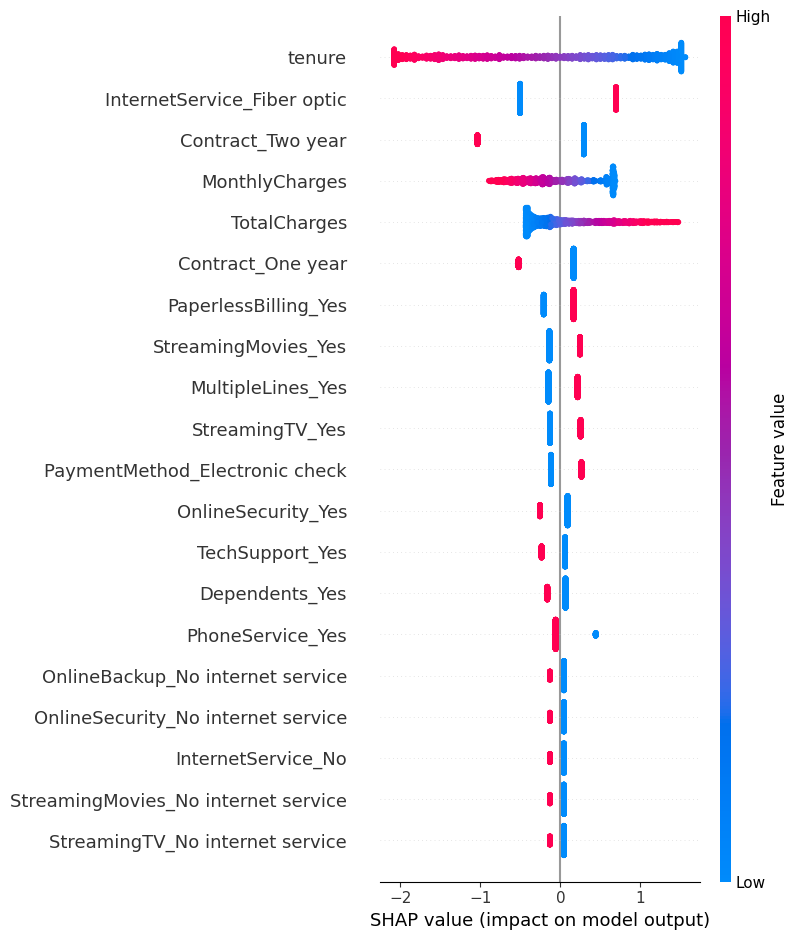

In [6]:
shap.summary_plot(shap_values, features=X_test_transformed, feature_names=feature_names)

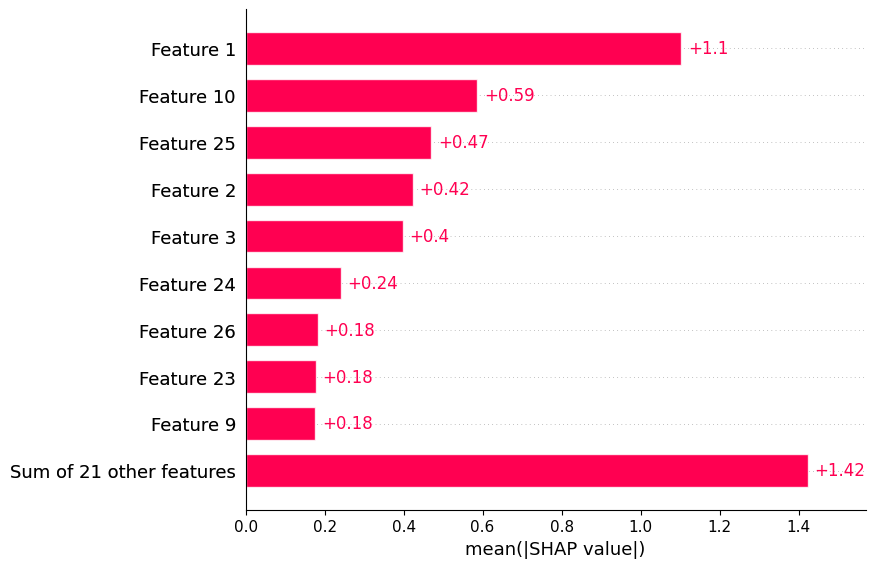

In [7]:
shap.plots.bar(shap_values)

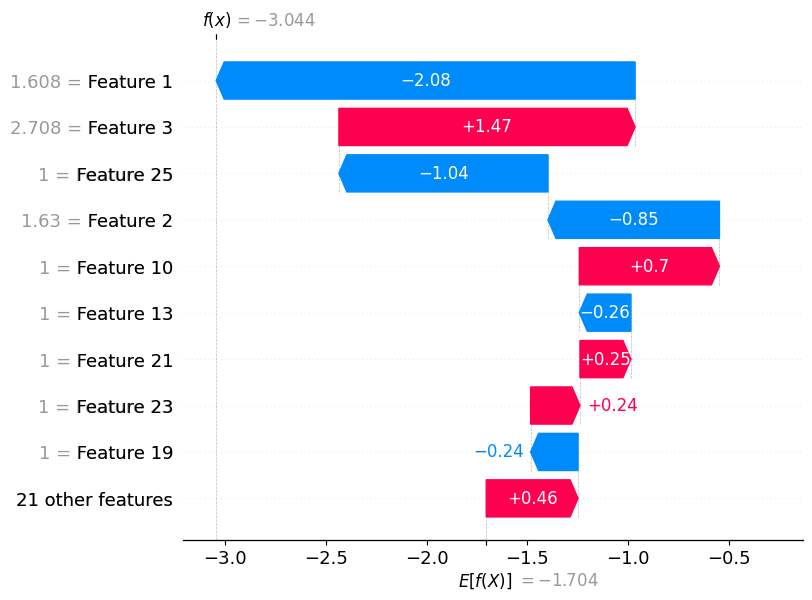

In [8]:
shap.plots.waterfall(shap_values[0])

Customers with short tenure and high monthly charges are the most likely to churn.

The analysis confirms that customer churn is strongly influenced by tenure and pricing-related factors, emphasizing the importance of early-stage customer engagement and cost management strategies.